
SIMULATED ANNEALING COOLING DEBUG

Fixed Parameters:
  Dataset: CAB10
  Alpha: 0.3
  LEVELS: 10
  sl: 10
  stage_length = sl * n = 100
  max_iterations = LEVELS * stage_length = 1000
  p0: 0.8
  n_samples: 50
  Output: plot only (no files saved)

Testing CAB10 - p=3, max_iterations=1000, alpha=0.3
Using LEVELS=10, sl=10, stage_length=100

[1/4] Testing initial_temp=None, beta=0.97, sl=10, p0=0.8, n_samples=50...
  Computed T0: 803000799.935754
  Target Tf (T0 * beta^max_iterations): 0.000047
  Cooling iterations generated: 1000
  Final plotted T: 0.000047

[2/4] Testing initial_temp=None, beta=0.98, sl=10, p0=0.8, n_samples=50...
  Computed T0: 835387450.383450
  Target Tf (T0 * beta^max_iterations): 1.405930
  Cooling iterations generated: 1000
  Final plotted T: 1.405930

[3/4] Testing initial_temp=None, beta=0.99, sl=10, p0=0.8, n_samples=50...
  Computed T0: 405158912.598043
  Target Tf (T0 * beta^max_iterations): 17491.215656
  Cooling iterations generated: 1000
  Final plotted T

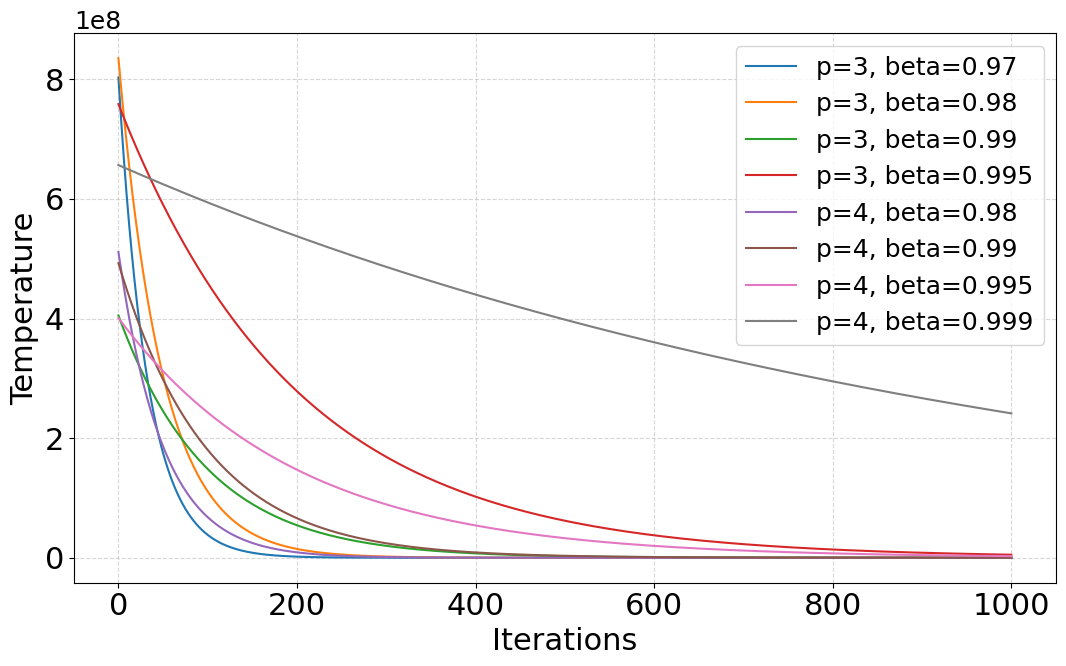

In [3]:
"""
Module: debug_sa.py
Description: Debug script to plot Simulated Annealing cooling schedules.

This script reproduces the SA setup used in parameter tuning for CAB10 and
plots temperature cooling curves for p=3 and p=4 using the current
round-2/final beta candidates (8 curves total).
No files are written.
"""

import os
import sys
import random
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 18})


def get_project_root():
    """Return project root for both script and notebook execution."""
    if "__file__" in globals():
        current_dir = os.path.dirname(os.path.abspath(__file__))
        return os.path.dirname(current_dir)

    candidate = os.path.abspath(os.getcwd())
    for _ in range(6):
        if (
            os.path.isdir(os.path.join(candidate, "src"))
            and os.path.isdir(os.path.join(candidate, "data"))
        ):
            return candidate
        parent = os.path.dirname(candidate)
        if parent == candidate:
            break
        candidate = parent

    return os.path.abspath(os.getcwd())


try:
    from .algorithms import _compute_initial_temperature
    from .functions import normalize_flow, initial_solution_closest
except ImportError:
    project_root = get_project_root()
    if project_root not in sys.path:
        sys.path.insert(0, project_root)

    from src.algorithms import _compute_initial_temperature
    from src.functions import normalize_flow, initial_solution_closest


def load_dataset(dataset_name="CAB10"):
    """Load one dataset and return (w, c, n)."""
    project_root = get_project_root()
    data_dir = os.path.join(project_root, "data")
    file_path = os.path.join(data_dir, "CAB_TR_and RGP Datasets_2026.xlsx")

    if dataset_name == "CAB10":
        n = 10
        w_skiprows = 2
        c_skiprows = 18
        usecols = "B:K"
        nrows = 10
        sheet_name = "CAB 10, 20 and 25Nodes"
    else:
        raise ValueError("This debug script is configured for CAB10 only.")

    w = pd.read_excel(
        file_path,
        sheet_name=sheet_name,
        header=None,
        usecols=usecols,
        skiprows=w_skiprows,
        nrows=nrows,
    )
    w = normalize_flow(w)

    c = pd.read_excel(
        file_path,
        sheet_name=sheet_name,
        header=None,
        usecols=usecols,
        skiprows=c_skiprows,
        nrows=nrows,
    )
    c = c.apply(pd.to_numeric, errors="coerce")

    return w, c, n


def build_cab10_sa_grid(p):
    """Create CAB10 SA tuning grid aligned with parameter_tuning_SA.py."""
    beta_candidates_by_p = {
        3: [0.97, 0.98, 0.990, 0.995],
        4: [0.98, 0.99, 0.995, 0.999],
    }

    beta_candidates = beta_candidates_by_p.get(p, [])
    p0 = 0.8
    n_samples = 50

    return [
        {
            "initial_temp": None,
            "beta": beta,
            "p0": p0,
            "n_samples": n_samples,
        }
        for beta in beta_candidates
    ]


def build_temperature_curve(initial_temperature, beta, stage_length, max_iterations):
    """Build per-iteration geometric cooling curve (current SA implementation).

    This cools the temperature at every move (iteration) by multiplying
    by `beta` for exactly `max_iterations` iterations, matching
    algorithms.simulated_annealing.
    """
    temperature = max(float(initial_temperature), 1e-12)
    final_temperature = max(temperature * (beta ** max_iterations), 1e-300)

    iterations = [0]
    temperatures = [temperature]

    # Classical SA: update temperature every iteration (move)
    for iteration in range(1, int(max_iterations) + 1):
        temperature *= beta
        iterations.append(iteration)
        temperatures.append(temperature)

    return iterations, temperatures, final_temperature


def debug_sa_cooling():
    """Print SA setup and plot cooling curves for CAB10 with p=3 and p=4."""
    dataset_name = "CAB10"
    alpha = 0.3
    levels = 10
    sl = 10
    p_values = [3, 4]

    w, c, n = load_dataset(dataset_name)
    stage_length = sl * n
    max_iterations = levels * stage_length

    print("\n" + "=" * 70)
    print("SIMULATED ANNEALING COOLING DEBUG")
    print("=" * 70)
    print("\nFixed Parameters:")
    print(f"  Dataset: {dataset_name}")
    print(f"  Alpha: {alpha}")
    print(f"  LEVELS: {levels}")
    print(f"  sl: {sl}")
    print(f"  stage_length = sl * n = {stage_length}")
    print(f"  max_iterations = LEVELS * stage_length = {max_iterations}")
    print("  p0: 0.8")
    print("  n_samples: 50")
    print("  Output: plot only (no files saved)")

    curves = []

    for p in p_values:
        sa_grid = build_cab10_sa_grid(p)
        print(f"\n{'='*70}")
        print(f"Testing {dataset_name} - p={p}, max_iterations={max_iterations}, alpha={alpha}")
        print(f"Using LEVELS={levels}, sl={sl}, stage_length={stage_length}")
        print(f"{'='*70}")

        total_tests = len(sa_grid)
        for idx, params in enumerate(sa_grid, start=1):
            beta = params["beta"]
            p0 = params["p0"]
            n_samples = params["n_samples"]

            print(
                f"\n[{idx}/{total_tests}] Testing initial_temp=None, beta={beta}, "
                f"sl={sl}, p0={p0}, n_samples={n_samples}..."
            )

            random.seed(1000 + p * 10 + idx)
            current_solution = initial_solution_closest(n, p, c)
            initial_temperature = _compute_initial_temperature(
                n=n,
                current_solution=current_solution,
                w=w,
                c=c,
                alpha=alpha,
                p0=p0,
                n_samples=n_samples,
                dataset_name=dataset_name,
            )

            iterations, temperatures, final_temperature = build_temperature_curve(
                initial_temperature=initial_temperature,
                beta=beta,
                stage_length=stage_length,
                max_iterations=max_iterations,
            )

            curves.append(
                {
                    "label": f"p={p}, beta={beta}",
                    "iterations": iterations,
                    "temperatures": temperatures,
                }
            )

            print(f"  Computed T0: {initial_temperature:.6f}")
            print(f"  Target Tf (T0 * beta^max_iterations): {final_temperature:.6f}")
            print(f"  Cooling iterations generated: {len(temperatures) - 1}")
            print(f"  Final plotted T: {temperatures[-1]:.6f}")

    plt.figure(figsize=(11, 7))
    for curve in curves:
        plt.plot(curve["iterations"], curve["temperatures"], label=curve["label"])

    # plt.title("SA Cooling Curves (CAB10): p=3 and p=4")
    plt.xlabel("Iterations", fontsize=22)
    plt.ylabel("Temperature", fontsize=22)
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


def main():
    debug_sa_cooling()


if __name__ == "__main__":
    main()

Saved: ts_vs_sa_comparison.pdf / .png


In [48]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

data = [
    ("p=3, α=0.3",  811.77,    811.77,    "Tie"),
    ("p=3, α=0.7",  966.62,    979.28,    "TS"),
    ("p=4, α=0.3",  758.87,    801.34,    "TS"),
    ("p=4, α=0.7",  937.02,    965.53,    "TS"),
    ("p=3, α=0.3",  4873.99,   4873.99,   "Tie"),
    ("p=3, α=0.7",  6385.32,   6375.75,   "SA"),
    ("p=5, α=0.3",  3512.66,   3818.56,   "TS"),
    ("p=5, α=0.7",  5390.07,   5441.83,   "TS"),
    ("p=3, α=0.3",  7454.18,   7454.18,   "Tie"),
    ("p=3, α=0.7",  9661.54,   9661.54,   "Tie"),
    ("p=5, α=0.3",  5672.47,   5694.51,   "TS"),
    ("p=5, α=0.7",  8529.13,   8597.04,   "TS"),
    ("p=4, α=0.3",   9335.24,   9246.25,   "SA"),
    ("p=4, α=0.7",   12004.21,  12004.21,  "Tie"),
    ("p=6, α=0.3",   8654.28,   7802.76,   "SA"),
    ("p=6, α=0.7",   11373.24,  11343.85,  "SA"),
    ("p=5, α=0.3",   20553.95,  20553.95,  "Tie"),
    ("p=5, α=0.7",   31129.20,  30588.47,  "SA"),
    ("p=7, α=0.3",   18133.74,  18217.85,  "TS"),
    ("p=7, α=0.7",   28556.85,  28041.81,  "SA"),
    ("p=9, α=0.3", 126224.72, 125692.60, "SA"),
    ("p=12, α=0.3",122407.79, 120395.71, "SA"),
]

labels   = [d[0] for d in data]
ts_costs = np.array([d[1] for d in data])
sa_costs = np.array([d[2] for d in data])
winners  = [d[3] for d in data]

TS_COL  = "#2563EB"
SA_COL  = "#DC2626"
TIE_COL = "#9CA3AF"

gaps       = []
bar_colors = []
bg_colors  = []

for i in range(len(data)):
    ts, sa, w = ts_costs[i], sa_costs[i], winners[i]
    if w == "TS":
        gaps.append((sa - ts) / ts * 100)
        bar_colors.append(TS_COL)
        bg_colors.append("#EFF6FF")
    elif w == "SA":
        gaps.append((ts - sa) / sa * 100)
        bar_colors.append(SA_COL)
        bg_colors.append("#FFF5F5")
    else:
        gaps.append(0.0)
        bar_colors.append(TIE_COL)
        bg_colors.append("#F9FAFB")

gaps  = np.array(gaps)
n     = len(labels)
y     = np.arange(n)
bar_h = 0.52

fig, ax = plt.subplots(figsize=(3.5, 6.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Background stripes
for i in range(n):
    ax.barh(y[i], 100, left=0, height=1.0,
            color=bg_colors[i], alpha=0.35, zorder=0)

# Bars
bars = ax.barh(y, gaps, height=bar_h, color=bar_colors, alpha=0.90, zorder=3)

# Labels: always just to the right of bar end
for i, bar in enumerate(bars):
    w = bar.get_width()
    if winners[i] == "Tie":
        ax.plot(0.08, y[i], marker='|', markersize=10,
                markeredgewidth=1.8, color=TIE_COL, zorder=5)
        ax.text(0.25, y[i], "Tie", va='center', ha='left',
                fontsize=9, color=TIE_COL, fontstyle='italic', fontweight='bold', zorder=6)
    else:
        ax.text(w + 0.12, y[i], f"{w:.2f}%",
                va='center', ha='left', fontsize=9,
                color=bar_colors[i], fontweight='bold', zorder=6)

# Axes
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10, fontfamily='monospace')
ax.set_xlabel("Cost gap between algorithms (%)", fontsize=10, labelpad=4)
# ax.set_title("TS vs. SA — Per-Instance Cost Gap",
            #  fontsize=6.5, fontweight='bold', pad=6)

max_gap = gaps.max()
ax.set_xlim(left=-0.15, right=max_gap * 1.35)
ax.xaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, zorder=0)
ax.tick_params(axis='x', labelsize=10)
ax.set_axisbelow(True)

# Dataset separator lines
for s in [4, 8, 12, 16, 20]:
    ax.axhline(s - 0.5, color='#CBD5E1', linewidth=0.8, linestyle='-', zorder=1)

# Dataset group labels
for ypos, dslabel in {1.5: "CAB10", 5.5: "CAB20", 9.5: "CAB25",
                      13.5: "TR40", 17.5: "TR55", 20.5: "RGP100"}.items():
    ax.text(-0.47, ypos, dslabel, va='center', ha='right',
            fontsize=10, color='#374151', fontweight='bold',
            transform=ax.get_yaxis_transform())

# Legend
ts_patch  = mpatches.Patch(color=TS_COL,  alpha=0.90, label='TS wins (bar = SA cost gap)')
sa_patch  = mpatches.Patch(color=SA_COL,  alpha=0.90, label='SA wins (bar = TS cost gap)')
tie_patch = mpatches.Patch(color=TIE_COL, alpha=0.6,  label='Tie (0% gap)')
ax.legend(handles=[ts_patch, sa_patch, tie_patch],
          fontsize=8, framealpha=0.85, edgecolor='#E5E7EB',
          loc='upper center', bbox_to_anchor=(-0.35, -0.032),
          ncol=1, handlelength=1.2, handleheight=0.8,
          borderpad=0.5, labelspacing=0.3)

# Summary
fig.text(0.6, -0.03, "TS wins: 8  |  SA wins: 8  |  Ties: 6",
         ha='center', fontsize=9, color='#6B7280', fontstyle='italic')

ax.invert_yaxis()
plt.subplots_adjust(left=0.26, right=0.97, top=0.95, bottom=0.07)

plt.savefig('visualizations/ts_vs_sa_comparison.pdf', dpi=800,
            bbox_inches='tight', facecolor='white')
plt.savefig('visualizations/ts_vs_sa_comparison.png', dpi=800,
            bbox_inches='tight', facecolor='white')
print("Saved to ./images")

Saved to ./images


# CW2 Summary Table

In [50]:
# import matplotlib.pyplot as plt
# import numpy as np

# scenarios = ['Baseline', 'Worst Case', 'IT Failure', 'Best Case']
# metrics = ['P(Delayed)', 'P(Financial Loss: Significant)', 'P(Reputation: Negative)', 'P(Operational Disruption: High)']

# data = {
#     'P(Delayed)':                        [37, 94, 94, 37],
#     'P(Financial Loss: Significant)':    [35, 80, 81, 35],
#     'P(Reputation: Negative)':           [31, 75, 76, 31],
#     'P(Operational Disruption: High)':   [36, 85, 85, 36],
# }

# colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# x = np.arange(len(scenarios))
# n = len(metrics)
# width = 0.18
# offsets = np.linspace(-(n - 1) / 2, (n - 1) / 2, n) * width

# fig, ax = plt.subplots(figsize=(13, 7))
# fig.patch.set_facecolor('#1e1e2e')
# ax.set_facecolor('#1e1e2e')

# bars_list = []
# for i, (metric, color) in enumerate(zip(metrics, colors)):
#     bars = ax.bar(x + offsets[i], data[metric], width, label=metric,
#                   color=color, alpha=0.88, edgecolor='white', linewidth=0.4)
#     bars_list.append(bars)
#     for bar in bars:
#         height = bar.get_height()
#         ax.text(bar.get_x() + bar.get_width() / 2, height + 1.2,
#                 f'{int(height)}%', ha='center', va='bottom',
#                 fontsize=7.5, color='white', fontweight='bold')

# ax.set_xlabel('Scenario', fontsize=13, color='white', labelpad=10)
# ax.set_ylabel('Probability (%)', fontsize=13, color='white', labelpad=10)
# ax.set_title('Risk Probability by Scenario', fontsize=16, color='white',
#              fontweight='bold', pad=18)

# ax.set_xticks(x)
# ax.set_xticklabels(scenarios, fontsize=12, color='white')
# ax.set_ylim(0, 110)
# ax.yaxis.set_tick_params(labelcolor='white', labelsize=10)

# ax.spines['bottom'].set_color('#555577')
# ax.spines['left'].set_color('#555577')
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='white')
# ax.set_axisbelow(True)

# legend = ax.legend(loc='upper left', fontsize=9, framealpha=0.25,
#                    labelcolor='white', facecolor='#2a2a3e', edgecolor='#555577',
#                    title='Risk Metrics', title_fontsize=10)
# legend.get_title().set_color('white')

# plt.tight_layout()
# plt.savefig('visualizations/risk_scenarios.png', dpi=800, bbox_inches='tight', facecolor='#1e1e2e')
# plt.show()

In [75]:
import matplotlib.pyplot as plt
import numpy as np

scenarios = ['Baseline', 'Worst Case', 'IT Failure', 'Best Case']
metrics = ['P(Delayed)', 'P(Financial Loss: Significant)', 'P(Reputation: Negative)', 'P(Operational Disruption: High)']

data = {
    'P(Delayed)':                        [79, 94, 94, 37],
    'P(Financial Loss: Significant)':    [68, 80, 81, 35],
    'P(Reputation: Negative)':           [64, 75, 76, 31],
    'P(Operational Disruption: High)':   [72, 85, 85, 36],
}

colors = ['#2563EB', '#F59E0B', '#10B981', '#EF4444']

x = np.arange(len(scenarios))
n = len(metrics)
width = 0.18
offsets = np.linspace(-(n - 1) / 2, (n - 1) / 2, n) * width

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + offsets[i], data[metric], width, label=metric,
                  color=color, alpha=0.85, edgecolor='black', linewidth=1)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 1.2,
                f'{int(height)}%', ha='center', va='bottom',
                fontsize=14, color='#333333', fontweight='bold')

ax.set_xlabel('Scenario', fontsize=22, color='#333333', labelpad=10)
ax.set_ylabel('Probability (%)', fontsize=22, color='#333333', labelpad=10)
# ax.set_title('Risk Probability by Scenario', fontsize=16, color='#111111',
            #  fontweight='bold', pad=18)

ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=22, color='#333333')
ax.set_ylim(0, 110)
ax.yaxis.set_tick_params(labelcolor='#333333', labelsize=22)

ax.spines['bottom'].set_color('#cccccc')
ax.spines['left'].set_color('#cccccc')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#cccccc')
ax.set_axisbelow(True)

legend = ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2,
                   fontsize=20, framealpha=1,
                   labelcolor='#333333', facecolor='white', edgecolor='#cccccc') # ,title='Risk Metrics', title_fontsize=12
legend.get_title().set_color('#111111')

plt.tight_layout()
plt.subplots_adjust(bottom=0.23)
plt.savefig('visualizations/risk_probability_by_scenario.png', dpi=800, bbox_inches='tight', facecolor='white')
plt.show()

# Sensitivity Analysis (for alpha)

In [85]:
"""
plot_alpha_sensitivity.py
-------------------------
Generates a grouped bar chart showing the percentage cost increase
from alpha=0.3 to alpha=0.7 for each instance, comparing Tabu Search
and Simulated Annealing.

Requires:
    - main_TS_results.csv
    - main_SA_results.csv

Output (saved to src/visualizations):
    - alpha_sensitivity.png
    - alpha_sensitivity.pdf
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def get_project_root():
    """Return project root for notebook/script execution."""
    candidate = os.path.abspath(os.getcwd())
    for _ in range(8):
        if (
            os.path.isdir(os.path.join(candidate, "src"))
            and os.path.isdir(os.path.join(candidate, "results"))
        ):
            return candidate
        parent = os.path.dirname(candidate)
        if parent == candidate:
            break
        candidate = parent
    return os.path.abspath(os.getcwd())


PROJECT_ROOT = get_project_root()
TS_CSV = os.path.join(PROJECT_ROOT, "results", "main_TS_results.csv")
SA_CSV = os.path.join(PROJECT_ROOT, "results", "main_SA_results.csv")
OUT_DIR = os.path.join(PROJECT_ROOT, "src", "visualizations")
os.makedirs(OUT_DIR, exist_ok=True)


def load_and_compute(ts_path, sa_path):
    """Load CSVs and compute percentage cost increase from alpha=0.3 to alpha=0.7."""
    ts = pd.read_csv(ts_path)
    sa = pd.read_csv(sa_path)

    for df in [ts, sa]:
        df["instance"] = df["dataset"] + "\np=" + df["p"].astype(str)

    def pct_increase(df):
        d03 = df[df["alpha"] == 0.3].copy()
        d07 = df[df["alpha"] == 0.7].copy()
        merged = d03.merge(d07, on="instance", suffixes=("_03", "_07"))
        merged["pct"] = (
            (merged["best_cost_07"] - merged["best_cost_03"])
            / merged["best_cost_03"] * 100
        )
        return merged[["instance", "pct"]]

    ts_pct = pct_increase(ts)
    sa_pct = pct_increase(sa)

    return ts_pct, sa_pct


def plot(ts_pct, sa_pct, out_dir):
    """Generate and save the grouped bar chart."""
    instances = ts_pct["instance"].tolist()
    ts_vals = ts_pct["pct"].values
    sa_vals = sa_pct["pct"].values

    x = np.arange(len(instances))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 5))

    bars_ts = ax.bar(
        x - width / 2,
        ts_vals,
        width,
        label="Tabu Search",
        color="#2166ac",
        alpha=0.85,
        edgecolor="white",
        linewidth=0.5,
    )

    bars_sa = ax.bar(
        x + width / 2,
        sa_vals,
        width,
        label="Simulated Annealing",
        color="#d6604d",
        alpha=0.85,
        edgecolor="white",
        linewidth=0.5,
    )

    for bar, color in [(bars_ts, "#2166ac"), (bars_sa, "#d6604d")]:
        for b in bar:
            ax.text(
                b.get_x() + b.get_width() / 2,
                b.get_height() + 0.5,
                f"{b.get_height():.1f}%",
                ha="center",
                va="bottom",
                fontsize=8,
                color=color,
                fontweight="bold",
            )

    ax.axhline(y=0, color="black", linewidth=0.8)

    for xb in [1.5, 3.5, 5.5, 7.5]:
        ax.axvline(x=xb, color="lightgray", linewidth=1, linestyle="--")

    group_centers = [0.5, 2.5, 4.5, 6.5, 8.5]
    group_labels = ["CAB10", "CAB20", "CAB25", "TR40", "TR55"]
    for gc, gl in zip(group_centers, group_labels):
        ax.text(gc, -6.5, gl, ha="center", va="top", fontsize=12, fontweight="bold", color="dimgray")

    ax.set_ylabel(r"Cost Increase from $\alpha=0.3$ to $\alpha=0.7$ (%)", fontsize=12)
    # ax.set_title(
    #     r"Sensitivity to Discount Factor $\alpha$: Percentage Cost Increase"
    #     "\n"
    #     r"from $\alpha=0.3$ to $\alpha=0.7$ by Instance and Algorithm",
    #     fontsize=11,
    #     fontweight="bold",
    # )
    instances = ['p = 3', 'p = 4', 'p = 3', 'p = 5', 'p = 3', 'p = 5', 'p = 4', 'p = 6', 'p = 5', 'p = 7']
    ax.set_xticks(x)
    ax.set_xticklabels(instances, fontsize=12)
    ax.set_ylim(0, 68)
    ax.legend(fontsize=12, loc="upper left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

    plt.tight_layout()

    for ext in ["png", "pdf"]:
        path = os.path.join(out_dir, f"alpha_sensitivity.{ext}")
        plt.savefig(path, bbox_inches="tight", dpi=800)
        print(f"Saved: {path}")

    plt.close()


ts_pct, sa_pct = load_and_compute(TS_CSV, SA_CSV)
plot(ts_pct, sa_pct, out_dir=OUT_DIR)
print(f"Output directory: {OUT_DIR}")

Saved: d:\UoE AI\SC\CW1\B286266_code\CW1\src\visualizations\alpha_sensitivity.png
Saved: d:\UoE AI\SC\CW1\B286266_code\CW1\src\visualizations\alpha_sensitivity.pdf
Output directory: d:\UoE AI\SC\CW1\B286266_code\CW1\src\visualizations


In [ ]:
isinstance

<function isinstance(obj, class_or_tuple, /)>